In [4]:
from bs4 import BeautifulSoup
import re
from textblob import TextBlob
from collections import Counter
import matplotlib.pyplot as plt

In [6]:
with open("Pygmalion.html") as fp:
    soup = BeautifulSoup(fp, 'html.parser')

text = soup.get_text()

start = text.find('ACT I')
end_phrase = "disports himself in a highly self-satisfied manner."
end_pos = text.find(end_phrase) + len(end_phrase)
play = text[start:end_pos]

print(f"Play length: {len(play)}")
print(play[-200:])

Play length: 0



In [7]:
idx = text.find("self-satisfied")
print(idx)
print(text[idx-100:idx+100])

161608
ut. Higgins, left alone, rattles his cash
in his pocket; chuckles; and disports himself in a highly
self-satisfied manner.






The rest of the story need not be shown in action, and indeed, would
ha


In [8]:
start = text.find('ACT I')
end_phrase = "self-satisfied manner."
end_pos = text.find(end_phrase) + len(end_phrase)
play = text[start:end_pos]

print(f"Play length: {len(play)}")
print(play[-300:])

Play length: 151737
rl, Henry. But never
mind, dear: I’ll buy you the tie and gloves.


HIGGINS [sunnily] Oh, don’t bother. She’ll buy em all right enough.
Good-bye.


They kiss. Mrs. Higgins runs out. Higgins, left alone, rattles his cash
in his pocket; chuckles; and disports himself in a highly
self-satisfied manner.


In [9]:
acts = re.split(r'(ACT [IVXLC]+)', play)
acts = [a.strip() for a in acts if a.strip()]

acts_dict = {}
for i in range(0, len(acts)-1, 2):
    label = acts[i].strip()
    content = acts[i+1].strip()
    acts_dict[label] = content

for act, content in acts_dict.items():
    print(f"{act}: {len(content)} characters")

ACT I: 20018 characters
ACT II: 49103 characters
ACT III: 27276 characters
ACT IV: 15034 characters
ACT V: 40246 characters


In [10]:
def extract_dialogue(text, character_label):
    pattern = rf'^{character_label}\.\s(.+?)(?=\n[A-Z]|\Z)'
    matches = re.findall(pattern, text, re.MULTILINE | re.DOTALL)
    dialogue = ' '.join(matches)
    # Remove stage directions in square brackets
    dialogue = re.sub(r'\[.*?\]', '', dialogue)
    return dialogue.strip()

In [11]:
eliza_labels = {
    'ACT I': 'THE FLOWER GIRL',
    'ACT II': 'LIZA',
    'ACT III': 'LIZA',
    'ACT IV': 'LIZA',
    'ACT V': 'LIZA'
}

eliza_dialogue = {}
for act, label in eliza_labels.items():
    eliza_dialogue[act] = extract_dialogue(acts_dict[act], label)

for act, dialogue in eliza_dialogue.items():
    print(f"{act}: {len(dialogue)} characters")

ACT I: 918 characters
ACT II: 2788 characters
ACT III: 1864 characters
ACT IV: 1485 characters
ACT V: 5807 characters


In [12]:
higgins_labels = {
    'ACT I': 'THE NOTE TAKER',
    'ACT II': 'HIGGINS',
    'ACT III': 'HIGGINS',
    'ACT IV': 'HIGGINS',
    'ACT V': 'HIGGINS'
}

higgins_dialogue = {}
for act, label in higgins_labels.items():
    higgins_dialogue[act] = extract_dialogue(acts_dict[act], label)

for act, dialogue in higgins_dialogue.items():
    print(f"{act}: {len(dialogue)} characters")

ACT I: 1172 characters
ACT II: 6287 characters
ACT III: 3386 characters
ACT IV: 2737 characters
ACT V: 5652 characters


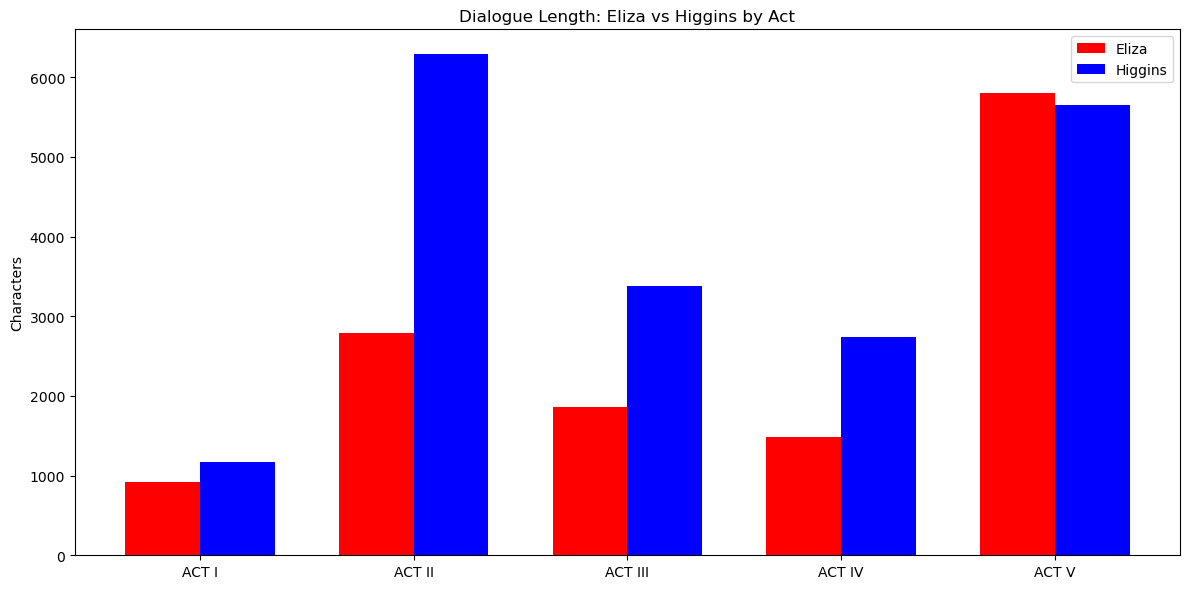

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width/2 for i in x], eliza_lengths, width, label='Eliza', color='red')
ax.bar([i + width/2 for i in x], higgins_lengths, width, label='Higgins', color='blue')
ax.set_title('Dialogue Length: Eliza vs Higgins by Act')
ax.set_xticks(x)
ax.set_xticklabels(acts_labels)
ax.set_ylabel('Characters')
ax.legend()
plt.tight_layout()
plt.savefig('pygmalion_dialogue_length.png', bbox_inches='tight', dpi=150)
plt.show()

In [14]:
from textblob import TextBlob

In [15]:
for act, dialogue in eliza_dialogue.items():
    polarity = TextBlob(dialogue).sentiment.polarity
    print(f"{act}: {polarity}")

ACT I: -0.08962121212121213
ACT II: 0.22675736961451248
ACT III: 0.12449388846447669
ACT IV: -0.014705882352941175
ACT V: 0.052666587598094436


In [16]:
for act, dialogue in higgins_dialogue.items():
    polarity = TextBlob(dialogue).sentiment.polarity
    print(f"{act}: {polarity}")

ACT I: -0.019794372294372295
ACT II: 0.13210433415790554
ACT III: -0.017366747835497836
ACT IV: -0.031128246753246748
ACT V: 0.02687328198991932


In [17]:
acts_labels = ['ACT I', 'ACT II', 'ACT III', 'ACT IV', 'ACT V']

eliza_scores = [TextBlob(eliza_dialogue[act]).sentiment.polarity for act in acts_labels]
higgins_scores = [TextBlob(higgins_dialogue[act]).sentiment.polarity for act in acts_labels]

print(eliza_scores)
print(higgins_scores)

[-0.08962121212121213, 0.22675736961451248, 0.12449388846447669, -0.014705882352941175, 0.052666587598094436]
[-0.019794372294372295, 0.13210433415790554, -0.017366747835497836, -0.031128246753246748, 0.02687328198991932]


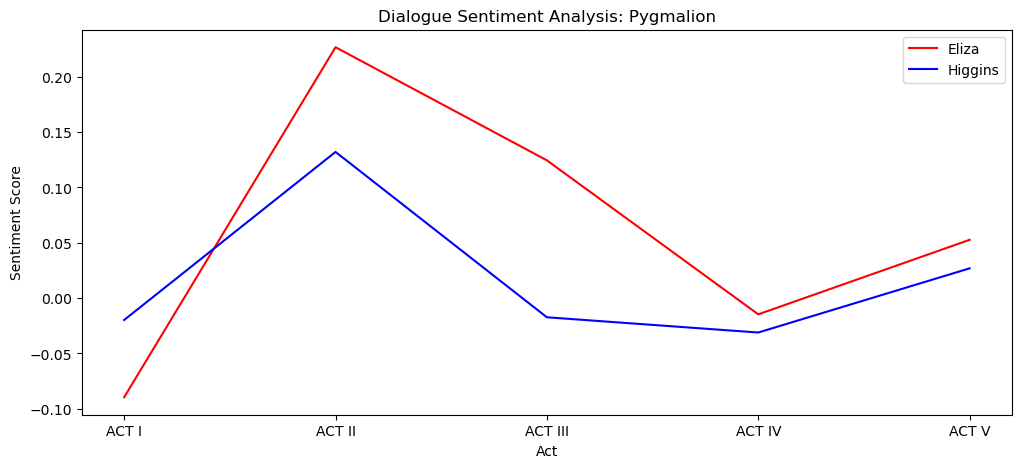

In [18]:
plt.figure(figsize=(12,5))     
plt.plot(acts_labels, eliza_scores, label='Eliza', color='red')  
plt.plot(acts_labels, higgins_scores, label='Higgins', color='blue')  
plt.title("Dialogue Sentiment Analysis: Pygmalion")         
plt.xlabel("Act")         
plt.ylabel("Sentiment Score")
plt.legend()
plt.savefig('dialogue_sentiment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
def get_context_words(text, name, window=10):
    words = re.findall(r'\b[a-zA-Z]+\b', text.lower())
    context = []
    for i, word in enumerate(words):
        if word == name.lower():
            context.extend(words[i-window:i+window])
    return context

In [20]:
eliza_context = get_context_words(play, "Eliza") + get_context_words(play, "Liza")
higgins_context = get_context_words(play, "Higgins")

print(len(eliza_context))
print(len(higgins_context))

5360
10740


In [22]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/e7064504-ddd6-401c-ad51-
[nltk_data]     fc9e2a17bdc4/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
eliza_custom_stops = {'eliza', 'liza', 'flower', 'girl', 'higgins', 'said', 'would', 'could'}
higgins_custom_stops = {'higgins', 'professor', 'liza', 'eliza', 'girl', 'henry', 'said', 'would', 'could'}

generic_stops = {'want', 'like', 'good', 'know', 'come', 'well', 'think', 'right', 'make', 'going', 'goes', 'back', 'quite', 'mean'}

eliza_filtered = [w for w in eliza_context if w not in stop_words and w not in eliza_custom_stops and w not in generic_stops and len(w) > 3]
higgins_filtered = [w for w in higgins_context if w not in stop_words and w not in higgins_custom_stops and w not in generic_stops and len(w) > 3]

eliza_counts = Counter(eliza_filtered)
higgins_counts = Counter(higgins_filtered)

print("ELIZA:")
print(eliza_counts.most_common(20))
print("\nHIGGINS:")
print(higgins_counts.most_common(20))


ELIZA:
[('pickering', 51), ('doolittle', 26), ('pearce', 24), ('door', 16), ('miss', 13), ('slippers', 12), ('colonel', 11), ('take', 10), ('sits', 10), ('shall', 9), ('thank', 9), ('silly', 9), ('talk', 9), ('eynsford', 9), ('hill', 9), ('half', 8), ('every', 8), ('away', 8), ('freddy', 8), ('call', 8)]

HIGGINS:
[('pickering', 130), ('pearce', 54), ('doolittle', 52), ('rising', 26), ('sits', 24), ('dear', 20), ('eynsford', 20), ('hill', 20), ('must', 18), ('door', 18), ('really', 17), ('colonel', 16), ('take', 16), ('anything', 16), ('coming', 16), ('told', 16), ('comes', 16), ('course', 16), ('parlor', 15), ('maid', 15)]


In [30]:
eliza_context = get_context_words(play, "Eliza") + get_context_words(play, "Liza")

In [31]:
print(play.lower().count("eliza"))
print(play.lower().count("liza"))
print(play.lower().count("flower girl"))

110
276
60


In [32]:
eliza_context = (get_context_words(play, "Eliza") + 
                 get_context_words(play, "Liza") + 
                 get_context_words(play, "flower"))

In [34]:
print(play.lower().count("eliza"))
print(play.lower().count("liza"))
print(play.lower().count("flower"))

110
276
81


In [35]:
eliza_counts = Counter(eliza_filtered)
print(eliza_counts.most_common(20))

[('pickering', 51), ('doolittle', 26), ('pearce', 24), ('door', 16), ('miss', 13), ('slippers', 12), ('colonel', 11), ('take', 10), ('sits', 10), ('shall', 9), ('thank', 9), ('silly', 9), ('talk', 9), ('eynsford', 9), ('hill', 9), ('half', 8), ('every', 8), ('away', 8), ('freddy', 8), ('call', 8)]


In [36]:
# 1. Rebuild context with flower
eliza_context = (get_context_words(play, "Eliza") + 
                 get_context_words(play, "Liza") + 
                 get_context_words(play, "flower"))

# 2. Filter
eliza_filtered = [w for w in eliza_context if w not in stop_words and w not in eliza_custom_stops and w not in generic_stops and len(w) > 3]

# 3. Count
eliza_counts = Counter(eliza_filtered)
print(eliza_counts.most_common(20))

[('pickering', 57), ('doolittle', 27), ('pearce', 25), ('door', 16), ('miss', 13), ('gentleman', 13), ('take', 12), ('shall', 12), ('slippers', 12), ('nothing', 12), ('half', 11), ('thank', 11), ('sits', 11), ('freddy', 11), ('colonel', 11), ('lady', 10), ('away', 10), ('always', 10), ('silly', 9), ('talk', 9)]


In [37]:
eliza_custom_stops = {'eliza', 'liza', 'flower', 'girl', 'higgins', 'said', 'would', 'could', 'pickering', 'doolittle', 'pearce', 'freddy'}
higgins_custom_stops = {'higgins', 'professor', 'liza', 'eliza', 'girl', 'henry', 'said', 'would', 'could', 'pickering', 'doolittle', 'pearce', 'freddy'}

In [40]:
eliza_context = (get_context_words(play, "Eliza") + 
                 get_context_words(play, "Liza") + 
                 get_context_words(play, "flower"))
higgins_context = (get_context_words(play, "Higgins") +
                   get_context_words(play, "professor"))

eliza_filtered = [w for w in eliza_context if w not in stop_words and w not in eliza_custom_stops and w not in generic_stops and len(w) > 3]
higgins_filtered = [w for w in higgins_context if w not in stop_words and w not in higgins_custom_stops and w not in generic_stops and len(w) > 3]

eliza_counts = Counter(eliza_filtered)
higgins_counts = Counter(higgins_filtered)
print(eliza_counts.most_common(20))
print(higgins_counts.most_common(20))

[('door', 16), ('miss', 13), ('gentleman', 13), ('take', 12), ('shall', 12), ('slippers', 12), ('nothing', 12), ('half', 11), ('thank', 11), ('sits', 11), ('colonel', 11), ('lady', 10), ('away', 10), ('always', 10), ('silly', 9), ('talk', 9), ('eynsford', 9), ('hill', 9), ('call', 9), ('professor', 9)]
[('rising', 27), ('sits', 24), ('door', 20), ('dear', 20), ('eynsford', 20), ('hill', 20), ('coming', 18), ('must', 18), ('colonel', 17), ('really', 17), ('course', 17), ('take', 16), ('anything', 16), ('told', 16), ('always', 16), ('comes', 16), ('thank', 15), ('miss', 15), ('parlor', 15), ('maid', 15)]
